# Introduction to Probabilistic Modeling

This notebook introduces the probabilistic-modeling primitives in `jax_fli`, and — more importantly — **which coordinate space the sampler actually traverses, and what you store**.

The recurring theme: a `TransformedDistribution` (white base `Normal(0,1)` + a coloring transform) does **not** automatically make the sampler move in the white base space. NumPyro / BlackJAX unconstrain every site through `biject_to(site.support)`, *not* through the distribution's own transforms. Getting genuine white-space geometry — and storing the right thing — takes a little care.

We cover:

1. **Bounded scalars** — `PreconditionnedUniform` / `ProbitTransform`, and why they need `TransformReparam` to sample in Gaussian space.
2. **A measurement** — probe the potential energy the sampler leapfrogs on, and see white $\tfrac12 u^2$ vs a colored / logit geometry directly.
3. **Initial-condition fields** — `DistributedNormal` (white noise) and `DistributedIC` (the colored field), the storage trade-off, and the recommended *sample-white → color-inline → recolor-at-write-time* pattern.

These building blocks feed the full Bayesian inference pipeline in the later notebooks.

## Setup

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
import numpyro
from jax.flatten_util import ravel_pytree
from jax.scipy.special import ndtr
from numpyro.handlers import reparam, seed
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.reparam import TransformReparam
from numpyro.infer.util import initialize_model

import jax_fli as jfli

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## 1. Custom distributions and MCMC

HMC / NUTS work best in an unconstrained, well-conditioned space. For a bounded parameter (say $\Omega_m \in [0.1, 0.5]$) we would like the sampler to move in a standard Gaussian and see the bounded value only downstream.

`PreconditionnedUniform` is built for this — a `TransformedDistribution` with base `Normal(0,1)` composed with:

- **`ProbitTransform`** — $\mathbb{R} \to (0,1)$ via the standard-normal CDF $\Phi$,
- **`AffineTransform`** — $(0,1) \to (\text{low}, \text{high})$.

**But here is the crucial subtlety.** A distribution's own `base_dist` + `.transforms` are used only by `.sample()` and `.log_prob()` (forward simulation and density). They are **not** what inference reparametrizes through. NumPyro / BlackJAX unconstrain a site via `biject_to(site.support)`:

- `PreconditionnedUniform.support = interval(low, high)` $\Rightarrow$ `biject_to(interval)` is the **logit** map (`SigmoidTransform ∘ AffineTransform`). So NUTS moves in **logit space**, and the `ProbitTransform` you built is *inert* — to the sampler this is behaviourally a plain `Uniform`.
- To actually put NUTS on the white base, wrap the site in **`TransformReparam`**. It rewrites the site into a latent `x_base ~ Normal(0,1)` (support `Real` $\Rightarrow$ `biject_to = Identity` $\Rightarrow$ genuine white geometry) and applies the transform as a deterministic link.

The next cell samples *with* `TransformReparam`, so it is correct; the measurement a couple of cells below shows what happens *without* it.

In [2]:
def simple_model():
    # Sample x from a preconditioned uniform on [-3, 3]
    # Under the hood, NUTS explores a standard Normal (the "base" space)
    with reparam(config={"x": TransformReparam()}):
        x = numpyro.sample(
            "x",
            jfli.infer.dist.PreconditionnedUniform(low=-3.0, high=3.0),
        )
    return x


# Run MCMC
kernel = NUTS(simple_model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=10_000, progress_bar=False)
mcmc.run(jax.random.PRNGKey(0))
samples = mcmc.get_samples()

The MCMC produces two related quantities:

- **`x`** — the parameter of interest, living in $[-3, 3]$ (what the model sees)
- **`x_base`** — the unconstrained Gaussian variable that NUTS actually explores

Let's visualize both to see the reparameterization in action.

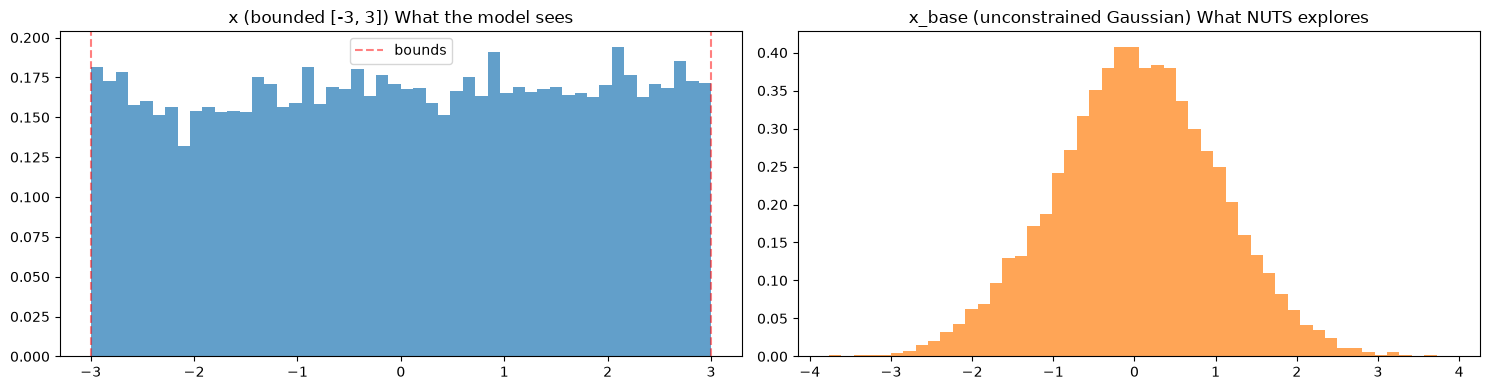

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))


# Final x in bounded space
axes[0].hist(samples["x"], bins=50, density=True, alpha=0.7, color="tab:blue")
axes[0].axvline(-3.0, color="red", linestyle="--", alpha=0.5)
axes[0].axvline(3.0, color="red", linestyle="--", alpha=0.5, label="bounds")
axes[0].set_title("x (bounded [-3, 3]) What the model sees")
axes[0].legend()
# Base space (unconstrained Gaussian)
axes[1].hist(samples["x_base"], bins=50, density=True, alpha=0.7, color="tab:orange")
axes[1].set_title("x_base (unconstrained Gaussian) What NUTS explores")

plt.tight_layout()
plt.show()

### Which space does the sampler actually traverse? Measure it.

Claims are cheap; let's measure. `initialize_model` hands back the `potential_fn` (= $-\log$ density, exactly what BlackJAX consumes) defined on the **unconstrained** latent. We sweep the latent coordinate $u$ and plot the potential $U(u)$ for three 1-D models:

1. `PreconditionnedUniform` **without** reparam — latent site `x`, support `interval` $\Rightarrow$ logit,
2. `PreconditionnedUniform` **with** `TransformReparam` — latent `x_base`, support `Real` $\Rightarrow$ white,
3. white `Normal(0,1)` + `ndtr` as a `deterministic` — latent `x_z`, support `Real` $\Rightarrow$ white (the "sample white, color downstream" pattern by hand).

If a model truly traverses white space its potential is the parabola $\tfrac12 u^2$. Note the probit must be `ndtr` (the Gaussian CDF) — a `sigmoid` would sample white but target the *wrong* distribution (a peaked bell, not a Uniform).

direct  : latent site = 'x'       | white 1/2 u^2? False
reparam : latent site = 'x_base'  | white 1/2 u^2? True
uniform : latent site = 'x'       | white 1/2 u^2? False
white   : latent site = 'x_z'     | white 1/2 u^2? True


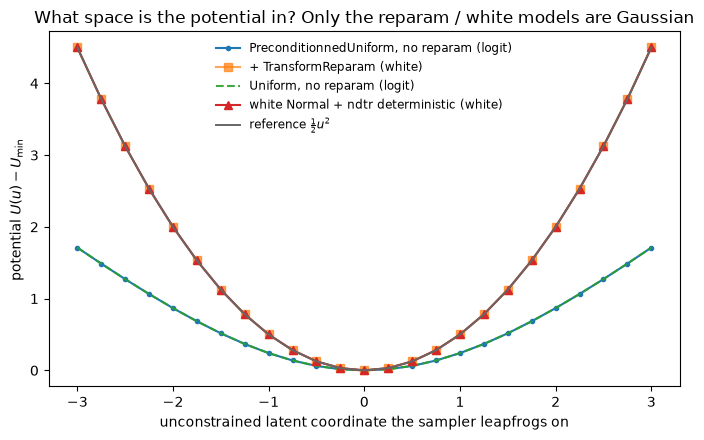

In [4]:
LOW, HIGH = -3.0, 3.0


def m_direct():
    numpyro.sample("x", jfli.infer.dist.PreconditionnedUniform(low=LOW, high=HIGH))


def m_uniform():
    numpyro.sample("x", numpyro.distributions.Uniform(low=LOW, high=HIGH))


def m_reparam():
    with reparam(config={"x": TransformReparam()}):
        numpyro.sample("x", jfli.infer.dist.PreconditionnedUniform(low=LOW, high=HIGH))


def m_white():
    z = numpyro.sample("x_z", numpyro.distributions.Normal(0.0, 1.0))
    numpyro.deterministic("x", LOW + (HIGH - LOW) * ndtr(z))  # probit (Gaussian CDF), NOT sigmoid


def potential_along_u(model, us):
    """Sweep the single unconstrained latent and return the (centered) potential energy."""
    mi = initialize_model(jax.random.PRNGKey(0), model, dynamic_args=False)
    _, unravel = ravel_pytree(mi.param_info.z)
    U = np.array([float(mi.potential_fn(unravel(jnp.array([u])))) for u in us])
    return U - U.min(), list(mi.param_info.z.keys())[0]


us = np.linspace(-3, 3, 25)
white = 0.5 * us**2
U_direct, k_direct = potential_along_u(m_direct, us)
U_reparam, k_reparam = potential_along_u(m_reparam, us)
U_uniform, k_uniform = potential_along_u(m_uniform, us)
U_white, k_white = potential_along_u(m_white, us)

print(f"direct  : latent site = {k_direct!r:9} | white 1/2 u^2? {np.allclose(U_direct, white, atol=1e-2)}")
print(f"reparam : latent site = {k_reparam!r:9} | white 1/2 u^2? {np.allclose(U_reparam, white, atol=1e-2)}")
print(f"uniform : latent site = {k_uniform!r:9} | white 1/2 u^2? {np.allclose(U_uniform, white, atol=1e-2)}")
print(f"white   : latent site = {k_white!r:9} | white 1/2 u^2? {np.allclose(U_white, white, atol=1e-2)}")

# The sampler traverses white space iff its potential is the 1/2 u^2 parabola.
assert not np.allclose(U_direct, white, atol=1e-2), "direct should be logit, not white"
assert np.allclose(U_reparam, white, atol=1e-2), "reparam should be white"
assert not np.allclose(U_uniform, white, atol=1e-2), "uniform should be logit, not white"
assert np.allclose(U_white, white, atol=1e-2), "white+ndtr should be white"

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(us, U_direct, ".-", label="PreconditionnedUniform, no reparam (logit)")
ax.plot(us, U_reparam, "s-", label="+ TransformReparam (white)", alpha=0.7)
ax.plot(us, U_uniform, "--", label="Uniform, no reparam (logit)", alpha=0.9)
ax.plot(us, U_white, "^-", label="white Normal + ndtr deterministic (white)")
ax.plot(us, white, "-", color="0.4", lw=1.4, label=r"reference $\frac{1}{2}u^2$")
ax.set_xlabel("unconstrained latent coordinate the sampler leapfrogs on")
ax.set_ylabel(r"potential $U(u) - U_{\min}$")
ax.set_title("What space is the potential in? Only the reparam / white models are Gaussian")
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

## 2. Initial-condition fields

Cosmological initial conditions are a Gaussian random field whose statistics are the matter power spectrum $P(k)$:

$$\delta(\mathbf{k}) = \sqrt{P(k)}\,\epsilon(\mathbf{k}), \qquad \epsilon \sim \mathcal{N}(0, 1).$$

The white field $\epsilon$ (or $z$) is well-conditioned (curvature $\approx 1$); the **colored** field $\delta$ has curvature $\propto 1/P(k)$, spanning orders of magnitude across scales — terrible for HMC. So we want to **sample white** but **run the forward model on the colored** field. `DistributedIC` is a `TransformedDistribution(base=white, transform=\sqrt{P(k)})`, so — exactly like `PreconditionnedUniform` — sampling it *directly* does **not** move in the white base (its `support` is `Real`, so NUTS leapfrogs on the colored $\delta$).

The four ways to set this up, and their trade-offs:

| approach | white traversal | stores | correct under cosmo-dependent coloring |
|---|---|---|---|
| `DistributedIC` / `PreconditionnedUniform`, no reparam | ✗ (colored / logit) | the transformed site | geometry wrong |
| `+ TransformReparam` | ✓ | white **and** colored (×2) | ✓ but double-storage |
| custom-constraint `biject_to` | ✓ | colored only | ✗ numerically broken (var 0.12 ≠ 1) |
| **white site + color at write-time** | ✓ | white `z` only (lossless) | ✓ |

The last row is the recommended pattern: sample a **white** site, color it **inline** (a local, *not* a `numpyro.deterministic`) to drive the forward model, and store only the white `z` — recoloring $\delta = \sqrt{P(k)}\,z$ at write-time. It is the only row that is white, single-storage, *and* robust when $P(k;\theta)$ changes with the sampled cosmology.

In [5]:
# Simulation parameters
mesh_size = (32, 32, 32)
box_size = (250.0, 250.0, 250.0)
cosmo = jc.Planck18()

### Recommended: sample white, color inline, recolor at write-time

Sample a **white** field with `DistributedNormal(0, 1)` (support `Real` $\Rightarrow$ the sampler genuinely moves in white space), then apply the power spectrum with `jfli.interpolate_initial_conditions` **as a local variable** — the same $\sqrt{P(k)}$ coloring `DistributedIC` wraps, but kept out of the trace. The forward model runs on the colored $\delta$; the trace keeps only the white field.

Crucially we do **not** call `numpyro.deterministic` on the colored field — that would store the giant array (see the `TransformReparam` caveat below). Instead we **recolor at write-time** from the stored white `z`. Since $\delta$ is a pure function of $(z, \text{cosmo})$, recomputing it is exact — the white `z` is a lossless, single-copy store.

In [6]:
def ic_model_white():
    # 1. WHITE site: support Real -> the sampler leapfrogs here, in well-conditioned white space.
    white = numpyro.sample(
        "white_noise",
        jfli.infer.dist.DistributedNormal(
            loc=jnp.zeros(mesh_size), scale=jnp.ones(mesh_size), mesh_size=mesh_size, box_size=box_size
        ),
    )
    # 2. Color INLINE as a local (NOT numpyro.deterministic) -> drives the forward model, stays out
    #    of the trace. This sqrt(P(k)) map is the same coloring DistributedIC wraps.
    delta = jfli.interpolate_initial_conditions(white.array, mesh_size, box_size, cosmo=cosmo)
    # forward_model(cosmo, delta) would continue from here.
    return white, delta


# The trace holds ONLY the white site: `delta` is a plain local, never a numpyro site.
trace = Predictive(ic_model_white, num_samples=1)(jax.random.PRNGKey(42))
print("stored trace keys:", list(trace.keys()), " <- only 'white_noise' is field-sized (no colored delta)")

# Run the model deterministically to grab both the white draw and the delta the forward model saw.
white_field, delta_model = seed(ic_model_white, jax.random.PRNGKey(42))()

# At write-time we persist only z; recolor to recover delta. Same function, same z -> identical.
z_stored = white_field.array
delta_writetime = jfli.interpolate_initial_conditions(z_stored, mesh_size, box_size, cosmo=cosmo)
assert jnp.allclose(delta_model.array, delta_writetime.array)
print(
    "recolor(stored z) reproduces the model's delta exactly:",
    bool(jnp.allclose(delta_model.array, delta_writetime.array)),
)
print(
    f"white z: {z_stored.nbytes / 1e6:.2f} MB   colored delta: {delta_model.array.nbytes / 1e6:.2f} MB   (same size -> store ONE, not both)"
)

stored trace keys: ['white_noise']  <- only 'white_noise' is field-sized (no colored delta)
recolor(stored z) reproduces the model's delta exactly: True
white z: 0.13 MB   colored delta: 0.13 MB   (same size -> store ONE, not both)


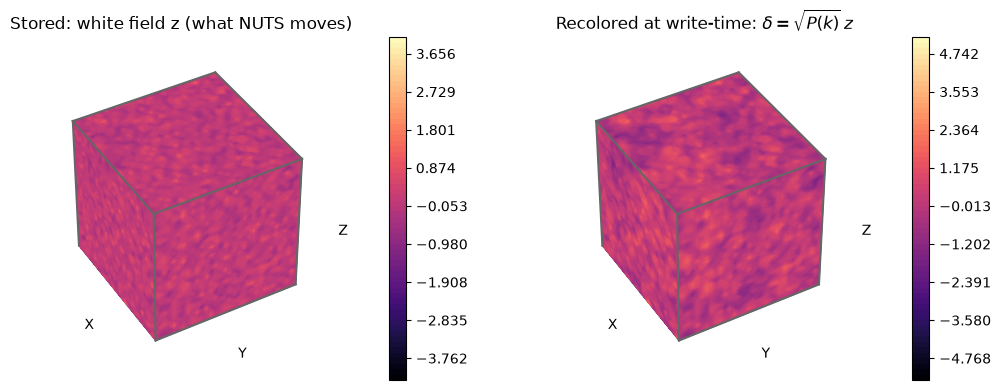

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), subplot_kw={"projection": "3d"})
white_field.plot(ax=axes[0], titles="Stored: white field z (what NUTS moves)")
delta_model.plot(ax=axes[1], titles=r"Recolored at write-time: $\delta = \sqrt{P(k)}\,z$")
plt.tight_layout()
plt.show()

### Why not `DistributedIC` directly — or with `TransformReparam`?

**Directly** (`numpyro.sample("initial_conditions", DistributedIC(...))`, no reparam) — exactly what the geometry probe showed for the scalar: `DistributedIC.support = Real`, so NUTS moves the **colored** $\delta$, with curvature $1/P(k)$ across orders of magnitude — statistically correct but badly conditioned. (The production `full_field_probmodel` *used* to sample this way; it now uses the recommended white pattern above.)

**With `TransformReparam`** — this *does* fix the geometry (NUTS moves the white `initial_conditions_base`). But `TransformReparam` internally calls `numpyro.deterministic` on the transformed value, so the trace ends up holding **both** the white base **and** the colored field — two field-sized arrays per sample, plus a re-run of the (cosmo-dependent) coloring at post-processing. At a $2560^3$ mesh that double-storage is fatal. Fine for a handful of cosmology scalars; wrong for the field.

The cell below shows both facts directly: the latent site each approach exposes, and the ×2 storage `TransformReparam` incurs.

In [8]:
def ic_direct():
    numpyro.sample(
        "initial_conditions", jfli.infer.dist.DistributedIC(mesh_size=mesh_size, box_size=box_size, cosmo=cosmo)
    )


def ic_reparam():
    with reparam(config={"initial_conditions": TransformReparam()}):
        numpyro.sample(
            "initial_conditions", jfli.infer.dist.DistributedIC(mesh_size=mesh_size, box_size=box_size, cosmo=cosmo)
        )


# What latent does the sampler actually move? Read it off initialize_model.
mi_direct = initialize_model(jax.random.PRNGKey(0), ic_direct, dynamic_args=False)
mi_reparam = initialize_model(jax.random.PRNGKey(0), ic_reparam, dynamic_args=False)
print("direct  latent (what NUTS moves):", list(mi_direct.param_info.z.keys()), "-> the COLORED field delta")
print("reparam latent (what NUTS moves):", list(mi_reparam.param_info.z.keys()), "-> the WHITE base z")

# TransformReparam double-storage: the post-processed trace holds BOTH the white base and colored field.
reparam_trace = Predictive(ic_reparam, num_samples=1)(jax.random.PRNGKey(42))
print("\nreparam trace (field-sized arrays it stores):")
for k, v in reparam_trace.items():
    arr = v.array if hasattr(v, "array") else v
    print(f"  {k:26s} shape={tuple(arr.shape)}")
print("-> both 'initial_conditions' (colored) and 'initial_conditions_base' (white) are stored: x2")

direct  latent (what NUTS moves): ['initial_conditions'] -> the COLORED field delta
reparam latent (what NUTS moves): ['initial_conditions_base'] -> the WHITE base z



reparam trace (field-sized arrays it stores):
  initial_conditions         shape=(1, 32, 32, 32)
  initial_conditions_base    shape=(1, 32, 32, 32)
-> both 'initial_conditions' (colored) and 'initial_conditions_base' (white) are stored: x2


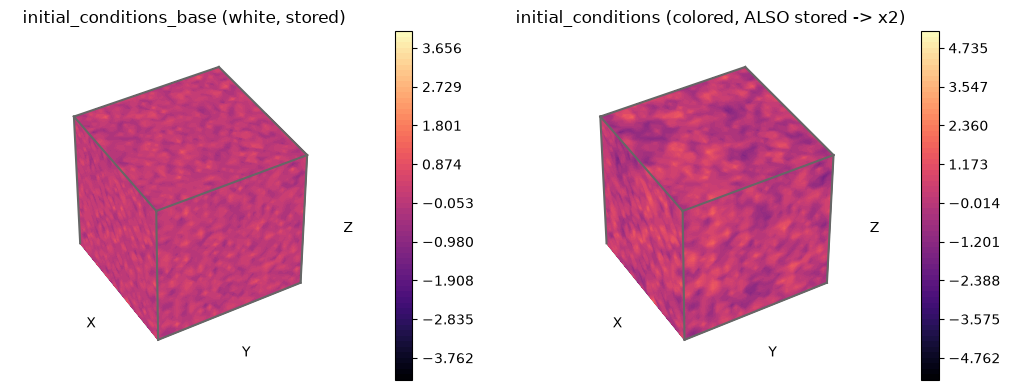

In [9]:
base = reparam_trace["initial_conditions_base"]
colored = reparam_trace["initial_conditions"]
base = base.replace(array=base.array[0])
colored = colored.replace(array=colored.array[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 4), subplot_kw={"projection": "3d"})
base.plot(ax=axes[0], titles="initial_conditions_base (white, stored)")
colored.plot(ax=axes[1], titles="initial_conditions (colored, ALSO stored -> x2)")
plt.tight_layout()
plt.show()

### Example: sampling a white field, and transformed cosmology

To avoid double storing the field, we sample a white field and color it inline. When saving the samples we can recolor.

For the scalar parameters we can afford to store both the white and colored versions, but for the field we cannot.

In [10]:
mesh_size = (32, 32, 32)
box_size = (250.0, 250.0, 250.0)


def model():
    # Cosmology in WHITE space: TransformReparam on the bounded priors, so NUTS moves the `<name>_base`
    # Gaussians. Double-storing the small cosmo scalars (base + physical) is fine.
    with reparam(config={"Omega_c": TransformReparam(), "sigma8": TransformReparam()}):
        omega_c = numpyro.sample("Omega_c", jfli.infer.dist.PreconditionnedUniform(low=0.2, high=0.4))
        sigma8 = numpyro.sample("sigma8", jfli.infer.dist.PreconditionnedUniform(low=0.7, high=1.0))
    cosmo = jc.Planck18(Omega_c=omega_c, sigma8=sigma8)

    # WHITE initial conditions (a plain DistributedNormal -> the site NUTS moves and the trace stores),
    # colored INLINE with interpolate_initial_conditions for the forward model (a local, not a site).
    white = numpyro.sample(
        "initial_conditions",
        jfli.infer.dist.DistributedNormal(
            loc=jnp.zeros(mesh_size), scale=jnp.ones(mesh_size), mesh_size=mesh_size, box_size=box_size
        ),
    )
    delta = jfli.interpolate_initial_conditions(white.array, mesh_size, box_size, cosmo=cosmo)
    # forward_model(cosmo, delta) would continue here.
    return white, delta

stored trace keys: ['Omega_c', 'Omega_c_base', 'initial_conditions', 'sigma8', 'sigma8_base']
  -> `initial_conditions` is WHITE; the cosmology (`Omega_c`, `sigma8`, their `_base`) is stored too.


sampled white IC: std 0.99 (~1, flat power)   used colored delta: std 1.126


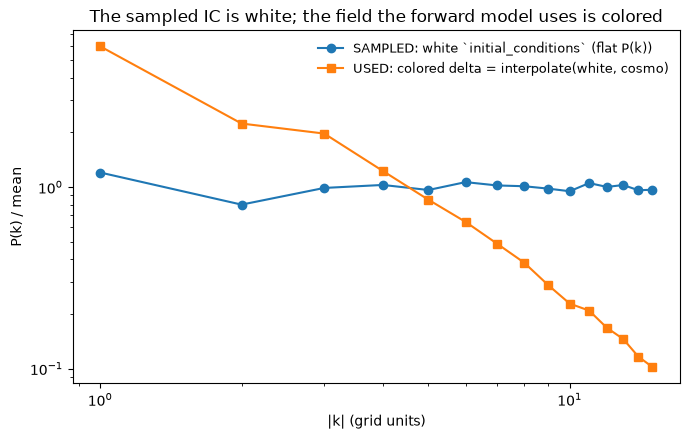

In [11]:
# Forward-sample once. The trace stores the WHITE `initial_conditions` and the cosmology params.
samples = Predictive(model, num_samples=1)(jax.random.PRNGKey(0))
print("stored trace keys:", list(samples.keys()))
print("  -> `initial_conditions` is WHITE; the cosmology (`Omega_c`, `sigma8`, their `_base`) is stored too.")

white_ic = np.asarray(samples["initial_conditions"].array[0])

# The forward model USES the colored field. Recolor the stored white IC with the ALREADY-STORED
# cosmology -> nothing to re-infer, cosmo is right there in the trace.
cosmo_stored = jc.Planck18(Omega_c=float(samples["Omega_c"][0]), sigma8=float(samples["sigma8"][0]))
delta = np.asarray(jfli.interpolate_initial_conditions(white_ic, mesh_size, box_size, cosmo=cosmo_stored).array)


def radial_power(field):
    """Radially-binned |field_k|^2 (a quick notebook diagnostic)."""
    n = field.shape[0]
    pk3d = np.abs(np.fft.fftn(field)) ** 2
    kf = np.fft.fftfreq(n) * n
    kmag = np.sqrt(sum(g**2 for g in np.meshgrid(kf, kf, kf, indexing="ij")))
    kb = np.arange(1, n // 2)
    return kb, np.array([pk3d[(kmag >= b - 0.5) & (kmag < b + 0.5)].mean() for b in kb])


kb, pk_white = radial_power(white_ic)
_, pk_delta = radial_power(delta)
print(f"sampled white IC: std {white_ic.std():.2f} (~1, flat power)   used colored delta: std {delta.std():.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(kb, pk_white / pk_white.mean(), "o-", label="SAMPLED: white `initial_conditions` (flat P(k))")
ax.loglog(kb, pk_delta / pk_delta.mean(), "s-", label="USED: colored delta = interpolate(white, cosmo)")
ax.set_xlabel("|k| (grid units)")
ax.set_ylabel("P(k) / mean")
ax.set_title("The sampled IC is white; the field the forward model uses is colored")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# Sampling different kinds of fields

You can also sample other types of fields (e.g. lensing convergence) by changing the `field_type` argument in `DistributedNormal`. The use case would be sampling the observable for example and this can be done in the following way:


In [12]:
nside = 256
flatsky_npix = (256, 256)
field_size = (10.0, 10.0)


def dens_model():
    """Sample ICs directly via DistributedIC + reparameterization."""
    spherical_density = numpyro.sample(
        "spherical_density",
        jfli.infer.dist.DistributedNormal(
            0.0,
            1.0,
            mesh_size=mesh_size,
            box_size=box_size,
            field_type="spherical",
            nside=nside,
            flatsky_npix=flatsky_npix,
            field_size=field_size,
        ),
    )
    flat_density = numpyro.sample(
        "flat_density",
        jfli.infer.dist.DistributedNormal(
            0.0,
            1.0,
            mesh_size=mesh_size,
            box_size=box_size,
            field_type="flat",
            nside=nside,
            flatsky_npix=flatsky_npix,
            field_size=field_size,
        ),
    )

    # You can also sample the observable directly with some sigma for the likelihood
    flat_sky = jax.random.normal(jax.random.PRNGKey(0), shape=flatsky_npix) * 0.1 + flat_density.array.mean()
    spherical_map = (
        jax.random.normal(jax.random.PRNGKey(1), shape=(12 * nside**2,)) * 0.1 + spherical_density.array.mean()
    )
    flat_sky = jfli.FlatDensity(
        array=flat_sky,
        mesh_size=mesh_size,
        box_size=box_size,
        nside=nside,
        flatsky_npix=flatsky_npix,
        field_size=field_size,
    )
    spherical_map = jfli.SphericalDensity(
        array=spherical_map,
        mesh_size=mesh_size,
        box_size=box_size,
        nside=nside,
        flatsky_npix=flatsky_npix,
        field_size=field_size,
    )

    numpyro.sample("flat_sky_field", jfli.infer.dist.DistributedNormal(loc=flat_sky, scale=0.3))
    numpyro.sample("spherical_sky_field", jfli.infer.dist.DistributedNormal(loc=spherical_map, scale=0.3))

    return spherical_density, flat_density


# Draw one forward sample
predictive = Predictive(dens_model, num_samples=1)
reparam_samples = predictive(jax.random.PRNGKey(42))

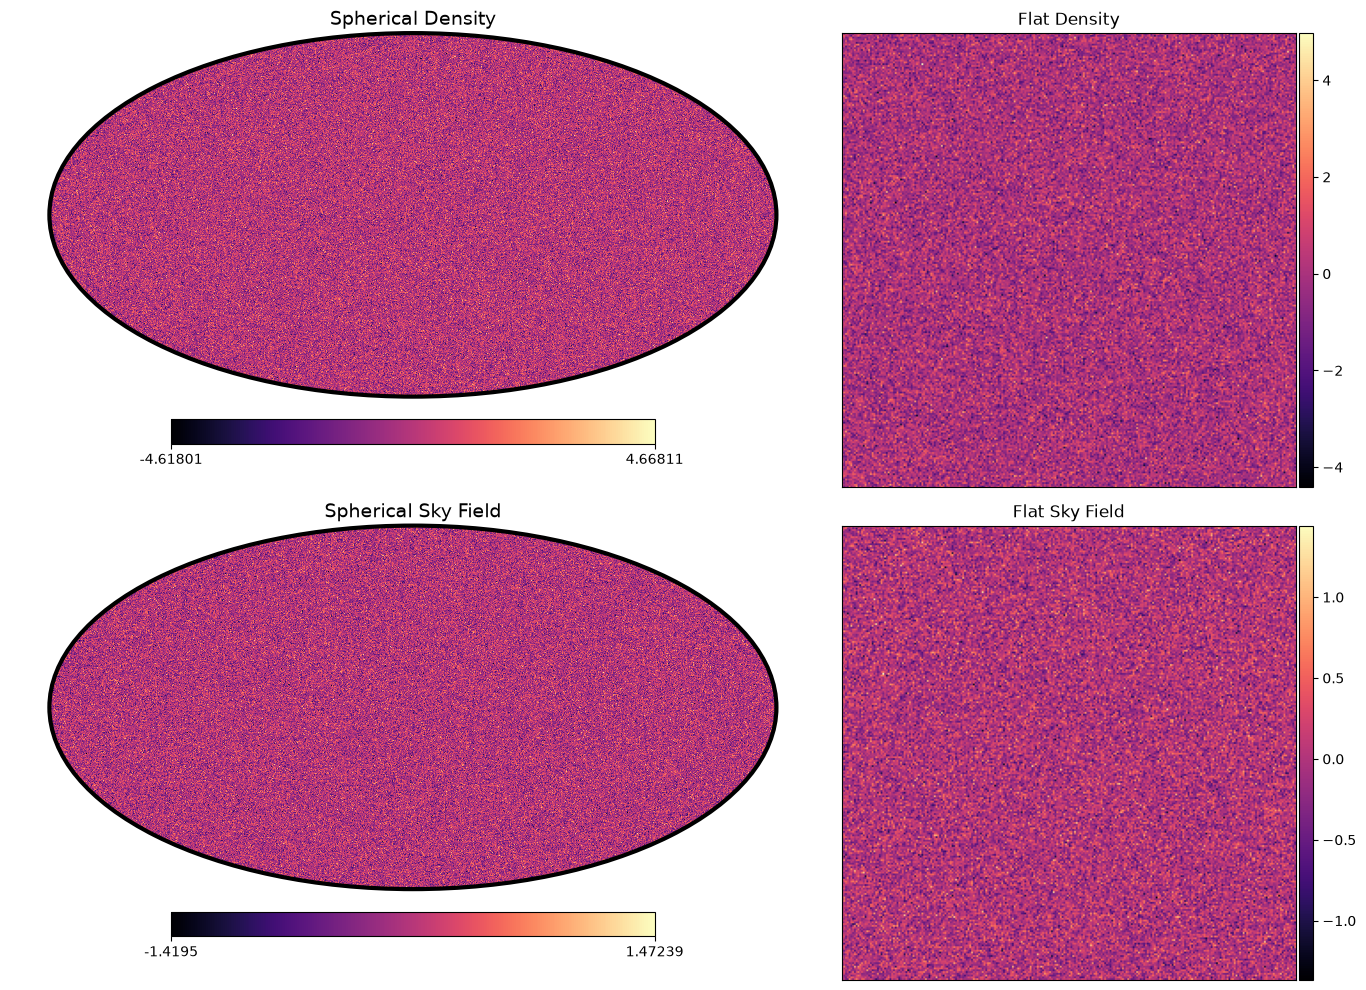

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()  # Flatten the 2D array of axes for easy indexing
reparam_samples["spherical_density"].plot(ax=ax[0], titles="Spherical Density")
reparam_samples["flat_density"].plot(ax=ax[1], titles="Flat Density")
reparam_samples["spherical_sky_field"].plot(ax=ax[2], titles="Spherical Sky Field")
reparam_samples["flat_sky_field"].plot(ax=ax[3], titles="Flat Sky Field")
plt.tight_layout()
plt.show()

# Using this inside an MCMC model  

A quick head's up: when using these distributions inside a NumPyro model, you must keep in mind that the sampled fields are stripepd from their field information as opposed to what happens when you are using `Predective` so in order to reconstruct the field you can do the following

In [14]:
nside = 256
flatsky_npix = (256, 256)
field_size = (10.0, 10.0)


def bad_sph_model():
    """Sample ICs directly via DistributedIC + reparameterization."""
    spherical_density = numpyro.sample(
        "spherical_density",
        jfli.infer.dist.DistributedNormal(
            0.0,
            1.0,
            mesh_size=mesh_size,
            box_size=box_size,
            field_type="spherical",
            nside=nside,
            flatsky_npix=flatsky_npix,
            field_size=field_size,
        ),
    )

    return spherical_density


# Draw one forward sample
predictive = Predictive(bad_sph_model, num_samples=1)
reparam_samples = predictive(jax.random.PRNGKey(42))

mcmc = MCMC(NUTS(bad_sph_model), num_warmup=1, num_samples=1)
mcmc.run(jax.random.PRNGKey(0))

samples = mcmc.get_samples()

print(f"Type of samples from predictive: {type(reparam_samples['spherical_density'])}")
print(f"Type of samples from MCMC: {type(samples['spherical_density'])}")

  0%|          | 0/2 [00:00<?, ?it/s]

warmup:  50%|█████     | 1/2 [00:00<00:00,  2.14it/s, 3 steps of size 7.85e+00. acc. prob=0.67]

sample: 100%|██████████| 2/2 [00:00<00:00,  3.86it/s, 1 steps of size 7.85e+00. acc. prob=0.00]

Type of samples from predictive: <class 'jax_fli.fields.lightcone.SphericalDensity'>
Type of samples from MCMC: <class 'jaxlib._jax.ArrayImpl'>


So in order to ensure the same behaviour you need to to this

In [15]:
nside = 16
flatsky_npix = (16, 16)
field_size = (10.0, 10.0)


def good_sph_model():
    """Sample ICs directly via DistributedIC + reparameterization."""
    spherical_density = numpyro.sample(
        "spherical_density",
        jfli.infer.dist.DistributedNormal(
            0.0,
            1.0,
            mesh_size=mesh_size,
            box_size=box_size,
            field_type="spherical",
            nside=nside,
            flatsky_npix=flatsky_npix,
            field_size=field_size,
        ),
    )
    if not isinstance(spherical_density, jfli.SphericalDensity):
        spherical_density = jfli.SphericalDensity(
            array=spherical_density,
            mesh_size=mesh_size,
            box_size=box_size,
            nside=nside,
        )
    numpyro.deterministic("spherical_density_meta_data", spherical_density.to_metadata())

    return spherical_density


# Draw one forward sample
predictive = Predictive(good_sph_model, num_samples=1)
reparam_samples = predictive(jax.random.PRNGKey(42))

mcmc = MCMC(NUTS(good_sph_model), num_warmup=1, num_samples=1)
mcmc.run(jax.random.PRNGKey(0))

samples = mcmc.get_samples()
samples["spherical_density"] = jfli.SphericalDensity.FromDensityMetadata(
    array=samples["spherical_density"], field=samples["spherical_density_meta_data"]
)

print(f"Type of samples from predictive: {type(reparam_samples['spherical_density'])}")
print(f"Type of samples from MCMC: {type(samples['spherical_density'])}")

  0%|          | 0/2 [00:00<?, ?it/s]

warmup:  50%|█████     | 1/2 [00:00<00:00,  2.47it/s, 3 steps of size 4.28e+00. acc. prob=0.33]

sample: 100%|██████████| 2/2 [00:00<00:00,  4.92it/s, 1 steps of size 4.28e+00. acc. prob=0.00]

Type of samples from predictive: <class 'jax_fli.fields.lightcone.SphericalDensity'>
Type of samples from MCMC: <class 'jax_fli.fields.lightcone.SphericalDensity'>


# Sharding

`DistributedNormal` and `DistributedIC` support sharding across multiple devices for large 3D fields. You can specify `mesh_size` and `box_size` to control the domain decomposition. The distribution will automatically shard the samples and apply the correct transforms in parallel. You only need to specify the `field_sharding` parameter and the sampled normal will be sharded across the devices. (a 1D sharding will be applied for the spherical fields)

for example


```python
density_field = numpyro.sample(
            "initial_conditions",
            jfli.infer.dist.DistributedIC(box_size=box_size, mesh_size=mesh_size, cosmo=cosmo, field_sharding=sharding),
        )
```

Or in case you are samopling the observable directly

```python
numpyro.sample("kappa", jfli.infer.dist.DistributedNormal(loc=sharded_spherical_map , scale=0.3))
```

The `field_sharding` is inferred from the field itself and no need to specify it again when sampling the observable.
